### Brain Tumor MRI Classification

This notebook builds a complete, production-grade image classification pipeline for
the **Brain Tumor MRI Dataset** (Kaggle)  which contains four
classes of brain MRI scans:

- `glioma`
- `meningioma`
- `notumor`
- `pituitary`

**How to get the data**: download the dataset from Kaggle
(`https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset`) and unzip
it so that `../dataset/` looks like:

```
dataset/
├── Training/
│   ├── glioma/
│   ├── meningioma/
│   ├── notumor/
│   └── pituitary/
└── Testing/
    ├── glioma/
    ├── meningioma/
    ├── notumor/
    └── pituitary/
```

### 1. Setup, Imports & Configuration



In [1]:
import os
import json
import time
import random
import copy
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler, random_split
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

CONFIG = {
    # --- paths -------------------------------------------------------------
    "data_root": Path("../dataset"),
    "train_dir": Path("../dataset/Training"),
    "test_dir": Path("../dataset/Testing"),
    "checkpoint_dir": Path("checkpoints"),
    "export_dir": Path("../backend/model_artifacts"),

    # --- reproducibility -----------------------------------------------
    "seed": 42,

    # --- image / preprocessing ------------------------------------------
    "image_size": 224,          # standard size, compatible with pretrained backbones
    "val_split": 0.15,          # carved out of the Training folder

    # --- training ------------------------------------------------------
    "batch_size": 32,
    "epochs": 40,
    "learning_rate": 3e-4,
    "weight_decay": 1e-4,       # L2 regularization -> fights overfitting
    "early_stopping_patience": 7,
    "lr_scheduler_patience": 3,
    "lr_scheduler_factor": 0.5,
    "num_workers": 2,

    # --- class imbalance -------------------------------------------------
    "imbalance_ratio_threshold": 1.5,  # majority/minority ratio above this triggers reweighting

    # --- calibration -----------------------------------------------------
    "calibration_max_iter": 200,
}

CONFIG["checkpoint_dir"].mkdir(parents=True, exist_ok=True)
CONFIG["export_dir"].mkdir(parents=True, exist_ok=True)


def set_seed(seed: int) -> None:
    """Fix every source of randomness so results are reproducible run-to-run.

    Reproducibility matters for debugging (was a change actually an
    improvement, or just a lucky seed?) and for trustworthy reporting.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(CONFIG["seed"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


### 2. Dataset Loading & Exploration



In [3]:
import os
from google.colab import files

# Upload your kaggle.json API key file when prompted
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download and unzip directly into ../dataset
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset
!mkdir -p ../dataset
!unzip -q brain-tumor-mri-dataset.zip -d ../dataset

Saving kaggle (1).json to kaggle (1).json
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:01<00:00, 129MB/s]



In [4]:
CLASS_NAMES = sorted([d.name for d in CONFIG["train_dir"].iterdir() if d.is_dir()])
print("Classes found:", CLASS_NAMES)

def count_images_per_class(root: Path) -> dict:
    """Count image files per class folder. Used for both exploration and
    later to decide whether class-imbalance handling is required."""
    counts = {}
    for cls in CLASS_NAMES:
        cls_dir = root / cls
        counts[cls] = len(list(cls_dir.glob("*.*"))) if cls_dir.exists() else 0
    return counts

train_counts = count_images_per_class(CONFIG["train_dir"])
test_counts = count_images_per_class(CONFIG["test_dir"])

print("Training images per class:", train_counts)
print("Testing images per class:", test_counts)
print("Total training images:", sum(train_counts.values()))
print("Total testing images:", sum(test_counts.values()))


Classes found: ['glioma', 'meningioma', 'notumor', 'pituitary']
Training images per class: {'glioma': 1400, 'meningioma': 1400, 'notumor': 1400, 'pituitary': 1400}
Testing images per class: {'glioma': 400, 'meningioma': 400, 'notumor': 400, 'pituitary': 400}
Total training images: 5600
Total testing images: 1600


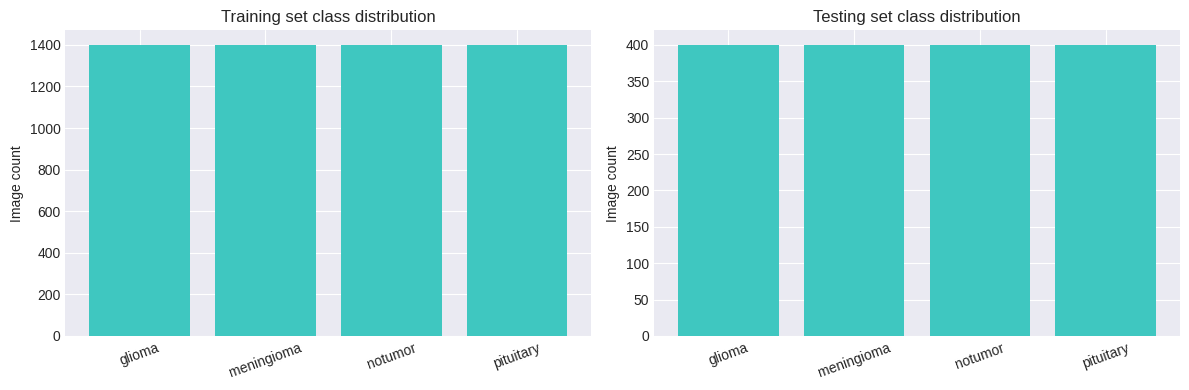

Class imbalance ratio (majority/minority): 1.00


In [5]:
# --- Class distribution visualization --------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, counts, title in zip(axes, [train_counts, test_counts], ["Training", "Testing"]):
    ax.bar(counts.keys(), counts.values(), color="#3FC7C0")
    ax.set_title(f"{title} set class distribution")
    ax.set_ylabel("Image count")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

# Imbalance ratio: majority class size / minority class size.
# A ratio close to 1.0 means the classes are roughly balanced; a large ratio
# means the model will be biased toward the majority class unless we correct
# for it (see Section 4, "Handling Class Imbalance").
majority, minority = max(train_counts.values()), min(train_counts.values())
imbalance_ratio = majority / minority
print(f"Class imbalance ratio (majority/minority): {imbalance_ratio:.2f}")


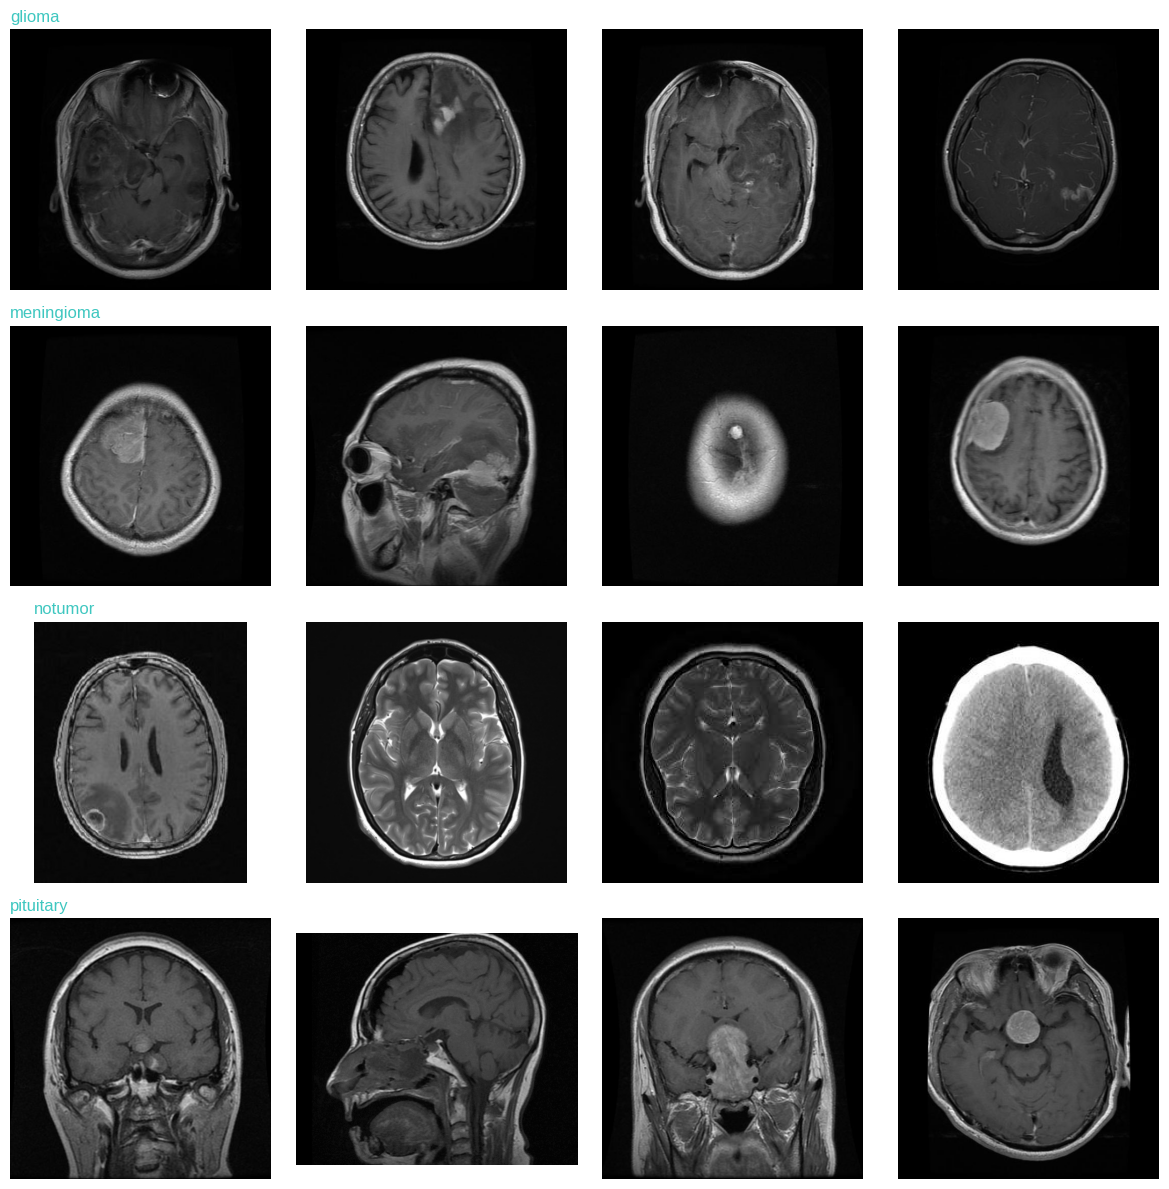

In [6]:
# --- Sample images per class -------------------------------------------------
fig, axes = plt.subplots(len(CLASS_NAMES), 4, figsize=(12, 3 * len(CLASS_NAMES)))
for row, cls in enumerate(CLASS_NAMES):
    cls_dir = CONFIG["train_dir"] / cls
    sample_paths = list(cls_dir.glob("*.*"))[:4]
    for col, img_path in enumerate(sample_paths):
        img = Image.open(img_path).convert("RGB")
        axes[row, col].imshow(img)
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(cls, fontsize=12)
    axes[row, 0].set_title(cls, loc="left", fontsize=12, color="#3FC7C0")
plt.tight_layout()
plt.show()


### 3. Preprocessing & Data Augmentation




In [7]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(CONFIG["image_size"], scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(CONFIG["image_size"]),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


### 4. Train/Validation/Test Split & Handling Class Imbalance




In [8]:
# ImageFolder expects `root/class_x/*.png` — exactly the Kaggle layout.
full_train_dataset = datasets.ImageFolder(CONFIG["train_dir"], transform=train_transforms)
test_dataset = datasets.ImageFolder(CONFIG["test_dir"], transform=eval_transforms)

assert full_train_dataset.classes == CLASS_NAMES, "Class order mismatch — check folder names."

# Stratified-ish split: split indices per class so train/val keep the same
# class proportions (a plain random_split can accidentally starve a class).
targets = np.array(full_train_dataset.targets)
train_idx, val_idx = [], []
rng = np.random.RandomState(CONFIG["seed"])
for cls_idx in range(len(CLASS_NAMES)):
    cls_indices = np.where(targets == cls_idx)[0]
    rng.shuffle(cls_indices)
    n_val = int(len(cls_indices) * CONFIG["val_split"])
    val_idx.extend(cls_indices[:n_val])
    train_idx.extend(cls_indices[n_val:])

# Validation must use eval_transforms (no augmentation) even though it comes
# from the same underlying folder as training, so we wrap it in a second
# ImageFolder instance pointed at eval-time transforms and share indices.
val_dataset_full = datasets.ImageFolder(CONFIG["train_dir"], transform=eval_transforms)

train_subset = torch.utils.data.Subset(full_train_dataset, train_idx)
val_subset = torch.utils.data.Subset(val_dataset_full, val_idx)

print(f"Train samples: {len(train_subset)} | Val samples: {len(val_subset)} | Test samples: {len(test_dataset)}")


Train samples: 4760 | Val samples: 840 | Test samples: 1600


In [9]:
# --- class weights & (optional) weighted sampler ----------------------------
train_targets = targets[train_idx]
class_sample_counts = np.array([np.sum(train_targets == i) for i in range(len(CLASS_NAMES))])
class_weights = class_sample_counts.sum() / (len(CLASS_NAMES) * class_sample_counts)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Per-class training counts:", dict(zip(CLASS_NAMES, class_sample_counts)))
print("Per-class loss weights:", dict(zip(CLASS_NAMES, np.round(class_weights, 3))))

use_weighted_sampler = imbalance_ratio > CONFIG["imbalance_ratio_threshold"]
print(f"Imbalance ratio {imbalance_ratio:.2f} > threshold {CONFIG['imbalance_ratio_threshold']} "
      f"-> using WeightedRandomSampler: {use_weighted_sampler}")

if use_weighted_sampler:
    sample_weights = class_weights[train_targets]
    sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
    train_loader = DataLoader(train_subset, batch_size=CONFIG["batch_size"], sampler=sampler,
                               num_workers=CONFIG["num_workers"], pin_memory=True)
else:
    train_loader = DataLoader(train_subset, batch_size=CONFIG["batch_size"], shuffle=True,
                               num_workers=CONFIG["num_workers"], pin_memory=True)

val_loader = DataLoader(val_subset, batch_size=CONFIG["batch_size"], shuffle=False,
                         num_workers=CONFIG["num_workers"], pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=CONFIG["batch_size"], shuffle=False,
                          num_workers=CONFIG["num_workers"], pin_memory=True)


Per-class training counts: {'glioma': np.int64(1190), 'meningioma': np.int64(1190), 'notumor': np.int64(1190), 'pituitary': np.int64(1190)}
Per-class loss weights: {'glioma': np.float64(1.0), 'meningioma': np.float64(1.0), 'notumor': np.float64(1.0), 'pituitary': np.float64(1.0)}
Imbalance ratio 1.00 > threshold 1.5 -> using WeightedRandomSampler: False


### 5. CNN Architecture




In [10]:
class ConvBlock(nn.Module):
    """Conv -> BatchNorm -> ReLU -> MaxPool -> Dropout, the repeating unit
    of the feature extractor."""

    def __init__(self, in_channels: int, out_channels: int, dropout: float = 0.3):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout2d(dropout),
        )

    def forward(self, x):
        return self.block(x)


class BrainTumorCNN(nn.Module):
    """Custom CNN for 4-class brain tumor MRI classification."""

    def __init__(self, num_classes: int, dropout_head: float = 0.5):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3, 32, dropout=0.2),     # 224 -> 112
            ConvBlock(32, 64, dropout=0.25),   # 112 -> 56
            ConvBlock(64, 128, dropout=0.3),   # 56 -> 28
            ConvBlock(128, 256, dropout=0.3),  # 28 -> 14
        )
        self.global_pool = nn.AdaptiveAvgPool2d(1)  # -> (batch, 256, 1, 1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_head),
            nn.Linear(128, num_classes),
        )
        # Keep a reference to the last conv layer for Grad-CAM hooking later.
        self.gradcam_target_layer = self.features[-1].block[3]  # last Conv2d in the final block

    def forward(self, x):
        x = self.features(x)
        x = self.global_pool(x)
        x = self.classifier(x)
        return x


model = BrainTumorCNN(num_classes=len(CLASS_NAMES)).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,} | Trainable: {trainable_params:,}")
print(model)


Total parameters: 1,207,844 | Trainable: 1,207,844
BrainTumorCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (7): Dropout2d(p=0.2, inplace=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(

### 6. Loss, Optimizer, LR Scheduler & Early Stopping


In [11]:
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["learning_rate"], weight_decay=CONFIG["weight_decay"])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=CONFIG["lr_scheduler_factor"], patience=CONFIG["lr_scheduler_patience"]
)


class EarlyStopping:
    """Stops training when validation loss has not improved for `patience`
    epochs, and keeps a copy of the best-performing model weights."""

    def __init__(self, patience: int = 7, min_delta: float = 1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float("inf")
        self.counter = 0
        self.best_state = None
        self.should_stop = False

    def step(self, val_loss: float, model: nn.Module) -> None:
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_state = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True


early_stopping = EarlyStopping(patience=CONFIG["early_stopping_patience"])


### 7. Training & Validation Loop



In [12]:
def run_epoch(model, loader, criterion, optimizer=None):
    """Runs one pass over `loader`. Training mode if `optimizer` is given,
    otherwise evaluation mode (no gradient updates)."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(is_train):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            if is_train:
                optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            if is_train:
                loss.backward()
                optimizer.step()

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total


history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}
best_ckpt_path = CONFIG["checkpoint_dir"] / "best_model.pth"

print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7} | {'LR':>8} | {'Time':>6}")
print("-" * 70)

for epoch in range(1, CONFIG["epochs"] + 1):
    start = time.time()

    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)

    elapsed = time.time() - start
    print(f"{epoch:>5} | {train_loss:>10.4f} | {train_acc:>9.4f} | {val_loss:>8.4f} | {val_acc:>7.4f} | {current_lr:>8.2e} | {elapsed:>5.1f}s")

    early_stopping.step(val_loss, model)
    if early_stopping.should_stop:
        print(f"\nEarly stopping triggered at epoch {epoch} (no val-loss improvement for {CONFIG['early_stopping_patience']} epochs).")
        break

# Restore and persist the best-performing weights, not just the last epoch's.
model.load_state_dict(early_stopping.best_state)
torch.save(model.state_dict(), best_ckpt_path)
print(f"\nBest model (val_loss={early_stopping.best_loss:.4f}) saved to {best_ckpt_path}")


Epoch | Train Loss | Train Acc | Val Loss | Val Acc |       LR |   Time
----------------------------------------------------------------------
    1 |     1.0621 |    0.5420 |   0.8247 |  0.6548 | 3.00e-04 |  48.9s
    2 |     0.9406 |    0.6124 |   0.8318 |  0.6798 | 3.00e-04 |  44.3s
    3 |     0.8961 |    0.6393 |   0.8343 |  0.6750 | 3.00e-04 |  44.5s
    4 |     0.8657 |    0.6517 |   0.7418 |  0.7143 | 3.00e-04 |  44.7s
    5 |     0.8401 |    0.6580 |   0.7009 |  0.7274 | 3.00e-04 |  43.3s
    6 |     0.8167 |    0.6607 |   0.7797 |  0.6702 | 3.00e-04 |  43.5s
    7 |     0.7947 |    0.6832 |   0.8228 |  0.6702 | 3.00e-04 |  44.6s
    8 |     0.7753 |    0.6924 |   0.7240 |  0.7143 | 3.00e-04 |  43.2s
    9 |     0.7846 |    0.6813 |   0.7356 |  0.7060 | 1.50e-04 |  43.4s
   10 |     0.7494 |    0.6966 |   0.7000 |  0.7179 | 1.50e-04 |  43.5s
   11 |     0.7229 |    0.7050 |   0.6955 |  0.7298 | 1.50e-04 |  44.2s
   12 |     0.7337 |    0.7061 |   0.7076 |  0.7167 | 1.50e-04 | 

### 8. Learning Curves



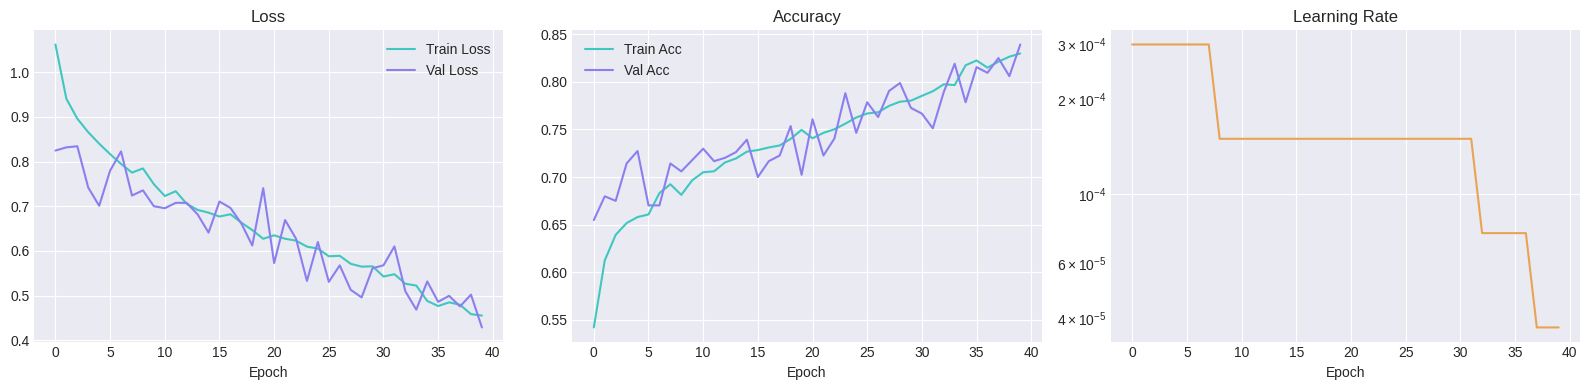

Final train/val loss gap: -0.0266 (small & stable => healthy generalization)


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history["train_loss"], label="Train Loss", color="#3FC7C0")
axes[0].plot(history["val_loss"], label="Val Loss", color="#8B7FF0")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["train_acc"], label="Train Acc", color="#3FC7C0")
axes[1].plot(history["val_acc"], label="Val Acc", color="#8B7FF0")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

axes[2].plot(history["lr"], color="#E8A354")
axes[2].set_title("Learning Rate")
axes[2].set_xlabel("Epoch")
axes[2].set_yscale("log")

plt.tight_layout()
plt.show()

gap = np.array(history["val_loss"]) - np.array(history["train_loss"])
print(f"Final train/val loss gap: {gap[-1]:.4f} (small & stable => healthy generalization)")


### 9. Full Evaluation on the Held-Out Test Set



In [14]:
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            preds = probs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


y_true, y_pred, y_probs = get_predictions(model, test_loader)

acc = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted")
macro_f1 = f1_score(y_true, y_pred, average="macro")

print(f"Test Accuracy:  {acc:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted):    {recall:.4f}")
print(f"F1 (weighted):        {f1:.4f}")
print(f"Macro F1:             {macro_f1:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


Test Accuracy:  0.7531
Precision (weighted): 0.7879
Recall (weighted):    0.7531
F1 (weighted):        0.7378
Macro F1:             0.7378

              precision    recall  f1-score   support

      glioma       0.99      0.50      0.66       400
  meningioma       0.69      0.55      0.61       400
     notumor       0.80      0.97      0.88       400
   pituitary       0.66      1.00      0.80       400

    accuracy                           0.75      1600
   macro avg       0.79      0.75      0.74      1600
weighted avg       0.79      0.75      0.74      1600



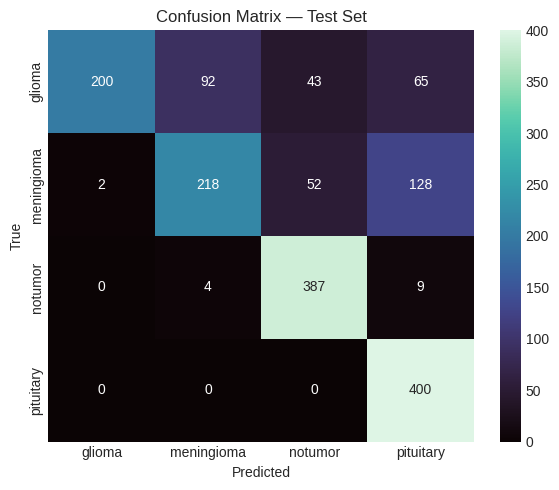

      glioma: 0.5000
  meningioma: 0.5450
     notumor: 0.9675
   pituitary: 1.0000


In [15]:
# --- Confusion matrix -----------------------------------------------------
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="mako", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()

# --- Per-class accuracy -----------------------------------------------------
per_class_acc = cm.diagonal() / cm.sum(axis=1)
for cls, a in zip(CLASS_NAMES, per_class_acc):
    print(f"{cls:>12}: {a:.4f}")


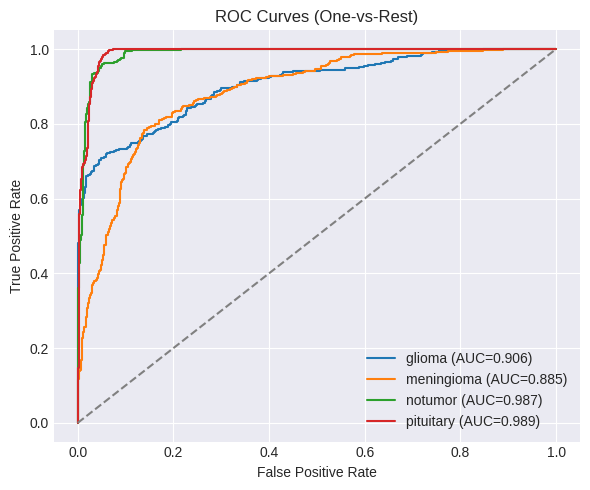

In [16]:
# --- Multiclass ROC curves (one-vs-rest) -----------------------------------
y_true_bin = label_binarize(y_true, classes=list(range(len(CLASS_NAMES))))

plt.figure(figsize=(6, 5))
for i, cls in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest)")
plt.legend()
plt.tight_layout()
plt.show()


### 10. Confidence Calibration (Temperature Scaling)



Learned temperature: 1.0377


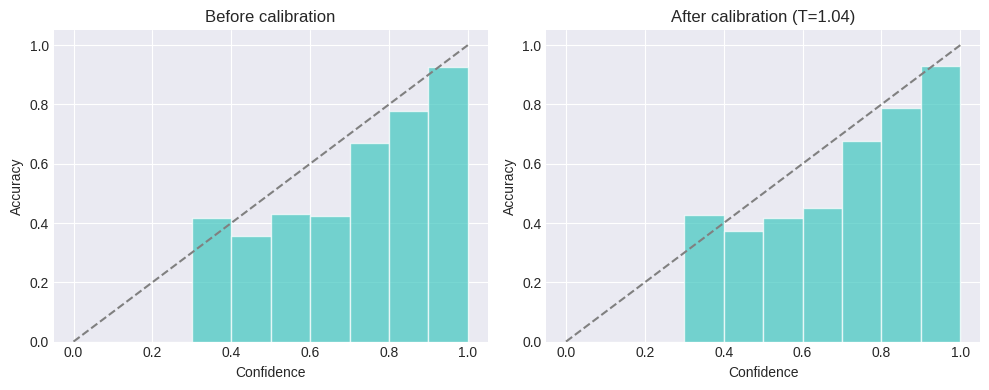

In [17]:
class TemperatureScaler(nn.Module):
    """Learns a single scalar temperature to calibrate softmax confidence,
    following Guo et al., 2017 ("On Calibration of Modern Neural Networks")."""

    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)

    def forward(self, logits):
        return logits / self.temperature


def collect_val_logits(model, loader):
    model.eval()
    logits_list, labels_list = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            logits_list.append(model(images).cpu())
            labels_list.append(labels)
    return torch.cat(logits_list), torch.cat(labels_list)


val_logits, val_labels = collect_val_logits(model, val_loader)

temp_scaler = TemperatureScaler()
nll_criterion = nn.CrossEntropyLoss()
optimizer_t = torch.optim.LBFGS([temp_scaler.temperature], lr=0.01, max_iter=CONFIG["calibration_max_iter"])

def _closure():
    optimizer_t.zero_grad()
    loss = nll_criterion(temp_scaler(val_logits), val_labels)
    loss.backward()
    return loss

optimizer_t.step(_closure)
learned_temperature = temp_scaler.temperature.item()
print(f"Learned temperature: {learned_temperature:.4f}")


def reliability_diagram(probs, labels, n_bins=10, ax=None, title=""):
    """Buckets predictions by confidence and plots predicted vs. actual
    accuracy per bucket -- a perfectly calibrated model lies on the diagonal."""
    confidences = probs.max(axis=1)
    predictions = probs.argmax(axis=1)
    accuracies = (predictions == labels).astype(float)

    bins = np.linspace(0, 1, n_bins + 1)
    bin_acc, bin_conf = [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (confidences > lo) & (confidences <= hi)
        if mask.sum() > 0:
            bin_acc.append(accuracies[mask].mean())
            bin_conf.append(confidences[mask].mean())
        else:
            bin_acc.append(0)
            bin_conf.append((lo + hi) / 2)

    ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
    ax.bar(bins[:-1], bin_acc, width=1 / n_bins, align="edge", alpha=0.7, color="#3FC7C0", edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel("Confidence")
    ax.set_ylabel("Accuracy")


# Compare uncalibrated vs. calibrated confidence on the test set
with torch.no_grad():
    test_logits, test_labels_t = collect_val_logits(model, test_loader)
    uncalibrated_probs = F.softmax(test_logits, dim=1).numpy()
    calibrated_probs = F.softmax(temp_scaler(test_logits), dim=1).numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
reliability_diagram(uncalibrated_probs, test_labels_t.numpy(), ax=axes[0], title="Before calibration")
reliability_diagram(calibrated_probs, test_labels_t.numpy(), ax=axes[1], title=f"After calibration (T={learned_temperature:.2f})")
plt.tight_layout()
plt.show()


### 11. Explainability — Grad-CAM



/tmp/ipykernel_1062/86565525.py:66: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


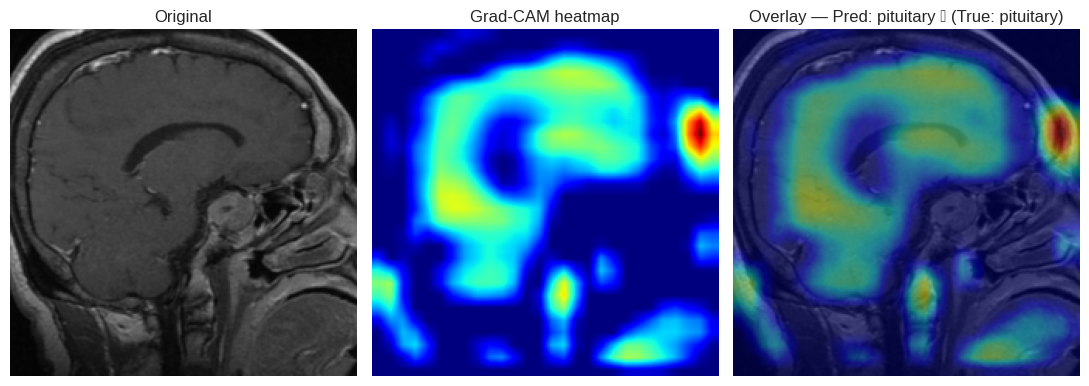

/tmp/ipykernel_1062/86565525.py:66: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


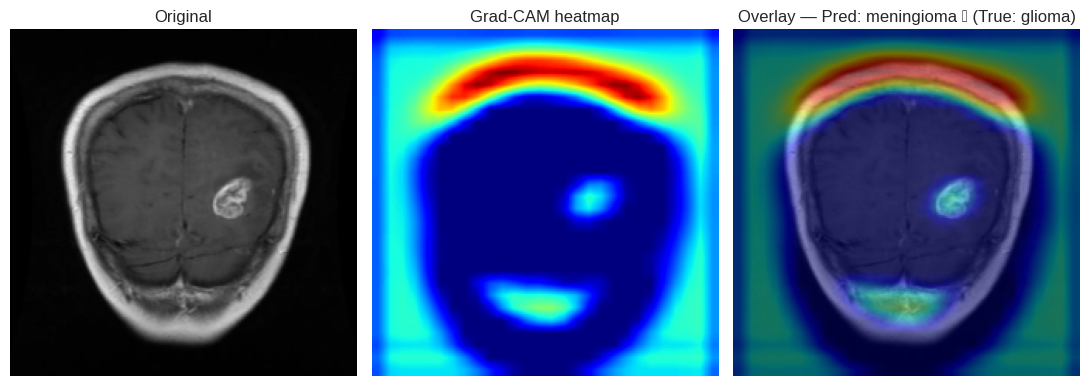

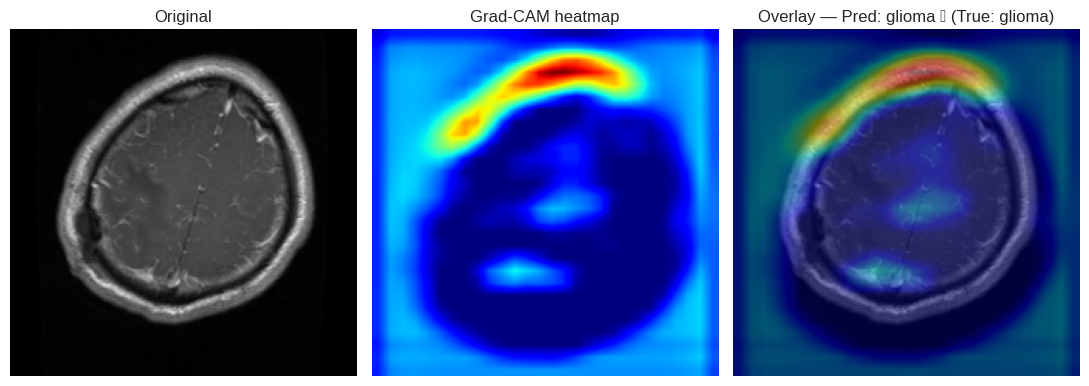

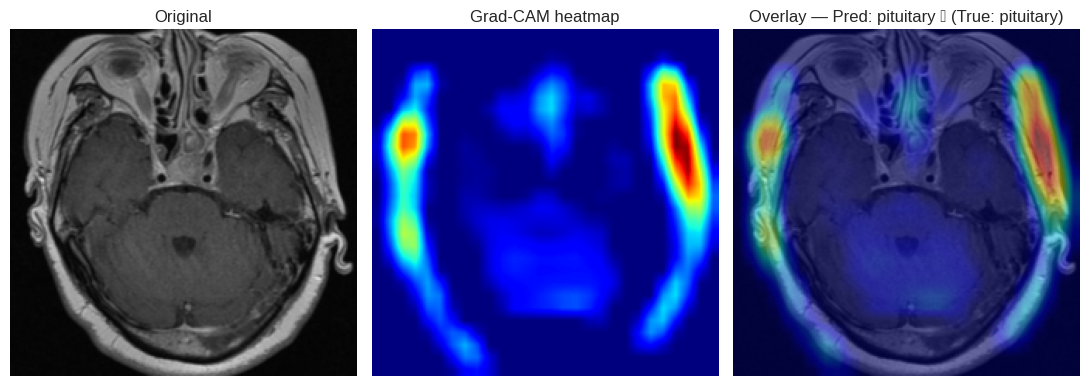

In [18]:
class GradCAM:
    """Grad-CAM for the custom BrainTumorCNN, hooking the last conv layer."""

    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model
        self.activations = None
        self.gradients = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor: torch.Tensor, class_idx: int = None):
        self.model.eval()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, class_idx].backward()

        # Global-average the gradients per channel -> importance weights
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=input_tensor.shape[-2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx


gradcam = GradCAM(model, model.gradcam_target_layer)


def denormalize(tensor):
    """Reverses ImageNet normalization for display purposes."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    img = tensor.cpu() * std + mean
    return img.clamp(0, 1).permute(1, 2, 0).numpy()


def show_gradcam(image_tensor, true_label_idx):
    input_tensor = image_tensor.unsqueeze(0).to(device)
    cam, pred_idx = gradcam.generate(input_tensor)
    original = denormalize(image_tensor)

    fig, axes = plt.subplots(1, 3, figsize=(11, 4))
    axes[0].imshow(original)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(cam, cmap="jet")
    axes[1].set_title("Grad-CAM heatmap")
    axes[1].axis("off")

    axes[2].imshow(original)
    axes[2].imshow(cam, cmap="jet", alpha=0.45)
    correct = "✓" if pred_idx == true_label_idx else "✗"
    axes[2].set_title(f"Overlay — Pred: {CLASS_NAMES[pred_idx]} {correct} (True: {CLASS_NAMES[true_label_idx]})")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()


# Show Grad-CAM for a few random test examples
sample_indices = random.sample(range(len(test_dataset)), 4)
for idx in sample_indices:
    img_tensor, label_idx = test_dataset[idx]
    show_gradcam(img_tensor, label_idx)


### 12. End-to-End Prediction Function



In [19]:
def predict_image(image_path: str, temperature: float = learned_temperature):
    image = Image.open(image_path).convert("RGB")
    input_tensor = eval_transforms(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(input_tensor)
        calibrated_logits = logits / temperature
        probs = F.softmax(calibrated_logits, dim=1).cpu().numpy()[0]

    pred_idx = int(probs.argmax())
    cam, _ = gradcam.generate(input_tensor, class_idx=pred_idx)

    return {
        "predicted_class": CLASS_NAMES[pred_idx],
        "confidence": float(probs[pred_idx]),
        "class_probabilities": {cls: float(p) for cls, p in zip(CLASS_NAMES, probs)},
        "gradcam_heatmap": cam,  # normalized [0, 1] array, same H×W as the input crop
    }


# Example usage on one test image
example_path = list((CONFIG["test_dir"] / CLASS_NAMES[0]).glob("*.*"))[0]
result = predict_image(str(example_path))
print(json.dumps({k: v for k, v in result.items() if k != "gradcam_heatmap"}, indent=2))


{
  "predicted_class": "glioma",
  "confidence": 0.7198490500450134,
  "class_probabilities": {
    "glioma": 0.7198490500450134,
    "meningioma": 0.06873726099729538,
    "notumor": 0.0005756880855187774,
    "pituitary": 0.2108379453420639
  }
}


### 13. Exporting the Model for the Backend



In [20]:
export_dir = CONFIG["export_dir"]
export_dir.mkdir(parents=True, exist_ok=True)

torch.save(model.state_dict(), export_dir / "model_weights.pth")

export_config = {
    "class_names": CLASS_NAMES,
    "image_size": CONFIG["image_size"],
    "resize_size": 256,
    "normalize_mean": IMAGENET_MEAN,
    "normalize_std": IMAGENET_STD,
    "temperature": learned_temperature,
    "architecture": "BrainTumorCNN",
    "test_accuracy": float(acc),
    "test_macro_f1": float(macro_f1),
}

with open(export_dir / "model_config.json", "w") as f:
    json.dump(export_config, f, indent=2)

print(f"Exported model weights + config to: {export_dir.resolve()}")
print(json.dumps(export_config, indent=2))


Exported model weights + config to: /backend/model_artifacts
{
  "class_names": [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
  ],
  "image_size": 224,
  "resize_size": 256,
  "normalize_mean": [
    0.485,
    0.456,
    0.406
  ],
  "normalize_std": [
    0.229,
    0.224,
    0.225
  ],
  "temperature": 1.0377150774002075,
  "architecture": "BrainTumorCNN",
  "test_accuracy": 0.753125,
  "test_macro_f1": 0.7377625747416359
}


In [23]:
import os
from google.colab import files

# Search for the model_artifacts folder location
possible_paths = [
    "/backend/model_artifacts",
    "/content/model_artifacts",
    "/content/backend/model_artifacts"
]

target_path = next((p for p in possible_paths if os.path.exists(p)), None)

if target_path:
    print(f"Found artifacts at: {target_path}")
    !zip -r /content/model_artifacts.zip {target_path}
    files.download("/content/model_artifacts.zip")
else:
    print("Could not find model_artifacts. Current root folders:")
    !ls -d /*/

Found artifacts at: /backend/model_artifacts
  adding: backend/model_artifacts/ (stored 0%)
  adding: backend/model_artifacts/model_weights.pth (deflated 8%)
  adding: backend/model_artifacts/model_config.json (deflated 43%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>